In [1]:
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import os
import pandas as pd
import pygmt
import rioxarray as rio
import shutil
import xarray as xr

In [ ]:
def getEnvRasters(age,dpath):
    ocean = f'{dpath}/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc'
    atmos = f'{dpath}/{age}Ma_nc_outputs/3000-12-30_plasim.nc'
    # try:
    #     oceanDS = xr.open_dataset(ocean).load()
    #     atmosDS = xr.open_dataset(atmos).load()
    # except FileNotFoundError as e:
    #     print('No data for this age')
    #     print(e)
    #     return None
    # except Exception as e:
    #     print(f'Some other error: \n{e}')
    #     return None
    with xr.open_dataset(atmos) as atmosDS:
        oceanDS = xr.open_dataset(ocean).interp_like(atmosDS) #Re-cast the goldstein coordinates into the same as plasim

        # Variables into xarray
        # Goldstein
        salinity = oceanDS['salinity'][0][0]
        upwelling = oceanDS['wvel'][0][1]
        # solarFlux = oceanDS['netsolar'][0]
        runoff = oceanDS['runoff'][0]
        bathymetry = oceanDS['bathymetry']

        # Plasim
        landsea = atmosDS['grid_landsea_mask']
        landseaNAN = xr.where(landsea>0.1, np.nan, 1) # To impose NaNs on land

        surfaceTemp = atmosDS['puma_temperature_surface']*landseaNAN
        SST_DJF = (atmosDS['DJF_GENIE_SST'] - 273.15)*landseaNAN
        SST_JJA = (atmosDS['JJA_GENIE_SST'] - 273.15)*landseaNAN
        solar = atmosDS['ebal_surface_solar_radiation']*landseaNAN
        solar_DJF = atmosDS['DJF_incoming_solar']*landseaNAN
        solar_JJA = atmosDS['JJA_incoming_solar']*landseaNAN

        oceanDS.close()
        atmosDS.close()

        # Combine seasonal data to get summer and winter means
        # SST
        SST_DJF_northern = SST_DJF.where(SST_DJF.latitude<0,0)
        SST_DJF_southern = SST_DJF.where(SST_DJF.latitude>0,0)

        SST_JJA_northern = SST_JJA.where(SST_JJA.latitude<0,0)
        SST_JJA_southern = SST_JJA.where(SST_JJA.latitude>0,0)

        SST_summer = SST_DJF_northern + SST_JJA_southern
        SST_winter = SST_DJF_southern + SST_JJA_northern

        # Solar Insolation
        solar_DJF_northern = solar_DJF.where(solar_DJF.latitude<0,0)
        solar_DJF_southern = solar_DJF.where(solar_DJF.latitude>0,0)

        solar_JJA_northern = solar_JJA.where(solar_JJA.latitude<0,0)
        solar_JJA_southern = solar_JJA.where(solar_JJA.latitude>0,0)

        solar_summer = solar_DJF_northern + solar_JJA_southern
        solar_winter = solar_DJF_southern + solar_JJA_northern

        # Remove white space from meta data
        # netsolar.attrs['long_name'] = 'netSolarHeatFlux'
        bathymetry.attrs['long_name'] = 'oceanDepth'
        upwelling.attrs['long_name'] = 'verticalCurrent'

        # Convert to geoTiff
        dpathStub = dpath.split('/')[-1] # Should be the model name
        envRasterPath = f'data/rasters/{dpathStub}/{age}Ma_envRaster'
        if os.path.exists(envRasterPath):
            shutil.rmtree(envRasterPath)
        os.makedirs(envRasterPath)

        surfaceTemp.rio.to_raster(f'{envRasterPath}/SST_annual.tif')
        SST_summer.rio.to_raster(f'{envRasterPath}/SST_summer.tif')
        # SST_winter.rio.to_raster(f'{envRasterPath}/SST_winter.tif')

        solar.rio.to_raster(f'{envRasterPath}/solar_annual.tif')
        # solar_summer.rio.to_raster(f'{envRasterPath}/solar_summer.tif')
        # solar_winter.rio.to_raster(f'{envRasterPath}/solar_winter.tif')

        # bathymetry.rio.to_raster(f'{envRasterPath}/bathymetry.tif')
        salinity.rio.to_raster(f'{envRasterPath}/salinity_annual.tif')
        # upwelling.rio.to_raster(f'{envRasterPath}/upwelling_annual.tif')
        # runoff.rio.to_raster(f'{envRasterPath}/runoff_annual.tif')

In [3]:
# age='10'
dpath=f'../climateModelData/2024-07-23_earthbyte_paleo_PaleomagRef_100'
for age in ['20','30']:
    print(age)
    getEnvRasters(age,dpath)


20


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/climateModelData/2024-07-23_earthbyte_paleo_PaleomagRef_100/20Ma_nc_outputs/3000-12-30_plasim.nc'

In [102]:
ages=np.arange(0,260,10)
co2s=['100']#,'200','280','560','1120','2240','4480','8960','17920','fosterCO2']
# age=0

# getEnvRasters(age,dpath)

for co2 in co2s:
    dpath=f'../climateModelData/2024-07-23_earthbyte_paleo_PaleomagRef_{co2}'
    for age in ages:
        age = str(age)
        print(f'{age}\n')
        getEnvRasters(age,dpath)
        # import time
        # time.sleep(1)

0

10

20



RuntimeError: only endian='native' allowed for NETCDF3 files, got 'big' (variable 'longitude', group '/')

In [11]:
age = '0'
co2 = '280'
dpathStub='2024-07-23_realigned_earthbyte_paleo_PaleomagRef'
dpath=f'../climateModelData/{dpathStub}_{co2}'

ocean = f'{dpath}/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc'
atmos = f'{dpath}/{age}Ma_nc_outputs/3000-12-30_plasim.nc'

oceanDS = xr.open_dataset(ocean)
oceanDS

atmosDS = xr.open_dataset(atmos)
atmosDS



<xarray.Dataset> Size: 2MB
Dimensions:                          (longitude: 64, latitude: 32, level: 10,
                                      month: 12)
Coordinates:
  * longitude                        (longitude) float32 256B 2.812 ... 357.2
  * latitude                         (latitude) float32 128B 85.76 ... -85.76
  * level                            (level) float32 40B 0.0383 ... 0.9833
  * month                            (month) int32 48B 1 2 3 4 5 ... 9 10 11 12
Data variables: (12/104)
    puma_temperature_surface_air     (latitude, longitude) float32 8kB ...
    puma_temperature_surface         (latitude, longitude) float32 8kB ...
    puma_temperature_soil            (latitude, longitude) float32 8kB ...
    puma_heat_flux_into_soil         (latitude, longitude) float32 8kB ...
    puma_precipitation_large_scale   (latitude, longitude) float32 8kB ...
    puma_precipitation_convective    (latitude, longitude) float32 8kB ...
    ...                               ...
    JJA_uspeed                       (level, latitude, longitude) float32 82kB ...
    SON_uspeed                       (level, latitude, longitude) float32 82kB ...
    DJF_vspeed                       (level, latitude, longitude) float32 82kB ...
    MAM_vspeed                       (level, latitude, longitude) float32 82kB ...
    JJA_vspeed                       (level, latitude, longitude) float32 82kB ...
    SON_vspeed                       (level, latitude, longitude) float32 82kB ...

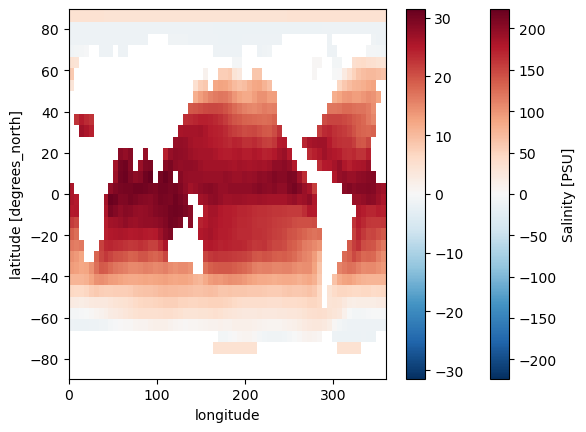

In [15]:
atmosDS = atmosDS.interp_like(oceanDS) #Re-cast the goldstein coordinates into the same as plasim

# Variables into xarray
# Goldstein
salinity = oceanDS['salinity'][0][0]
salinity.plot()
upwelling = oceanDS['wvel'][0][1]
# solarFlux = oceanDS['netsolar'][0]
runoff = oceanDS['runoff'][0]
bathymetry = oceanDS['bathymetry']

# Plasim

# To impose NaNs on land
landsea = atmosDS['grid_landsea_mask']
landseaNAN = xr.where(landsea>0.1, np.nan, 1)

surfaceTemp = atmosDS['puma_temperature_surface']*landseaNAN
SST_DJF = (atmosDS['DJF_GENIE_SST'] - 273.15)*landseaNAN
SST_JJA = (atmosDS['JJA_GENIE_SST'] - 273.15)*landseaNAN
solar = atmosDS['ebal_surface_solar_radiation']*landseaNAN
SST_JJA.plot()
solar_DJF = atmosDS['DJF_incoming_solar']*landseaNAN
solar_JJA = atmosDS['JJA_incoming_solar']*landseaNAN

/Users/jono/opt/anaconda3/envs/pyPlasimGenie/lib/python3.11/site-packages/pygmt/clib/session.py:1459: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing -5.532941264490927 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)


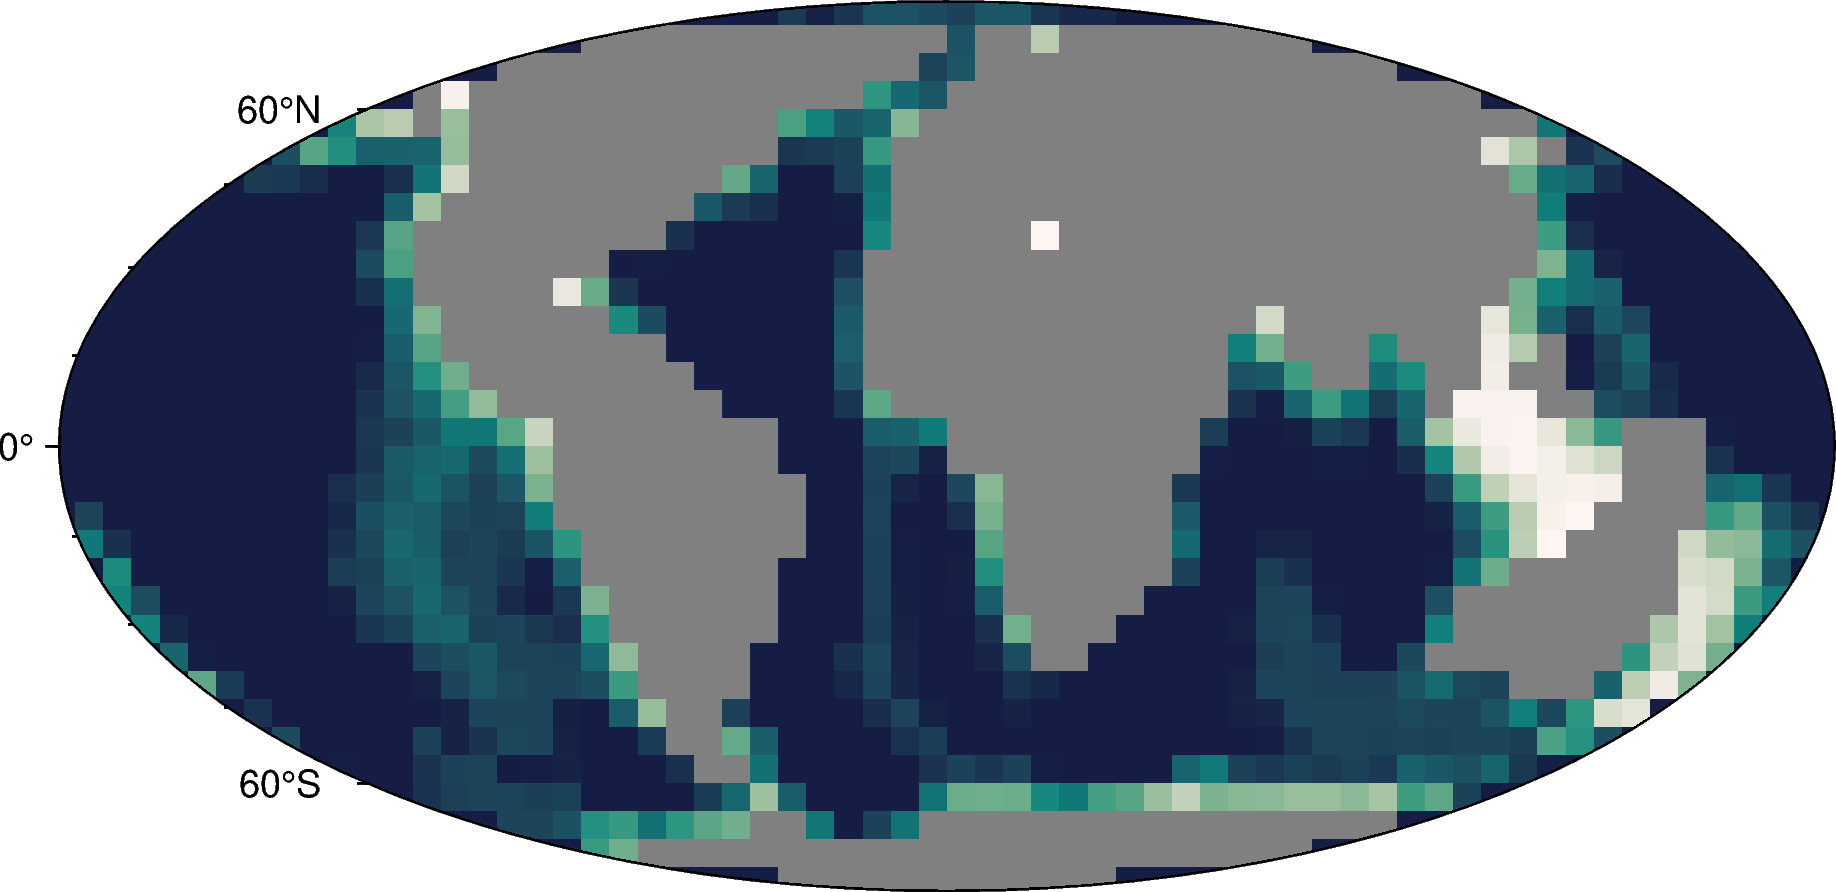

In [8]:
bathymetry
fig = pygmt.Figure()
fig.basemap(region="d", projection="W15c", frame=True)
fig.grdimage(bathymetry,cmap='tempo')
fig.show()

In [62]:
bathymetry

<xarray.DataArray 'bathymetry' (latitude: 32, longitude: 64)> Size: 8kB
array([[283.8467 , 283.8467 , 283.8467 , ..., 283.8467 , 283.8467 ,
        283.8467 ],
       [281.11533, 281.11533, 281.11533, ..., 281.11533, 281.11533,
        281.11533],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 256B 2.812 8.438 14.06 ... 345.9 351.6 357.2
  * latitude   (latitude) float32 128B 85.76 80.27 74.74 ... -80.27 -85.76
Attributes:
    long_name:  Ocean depth
    units:      m

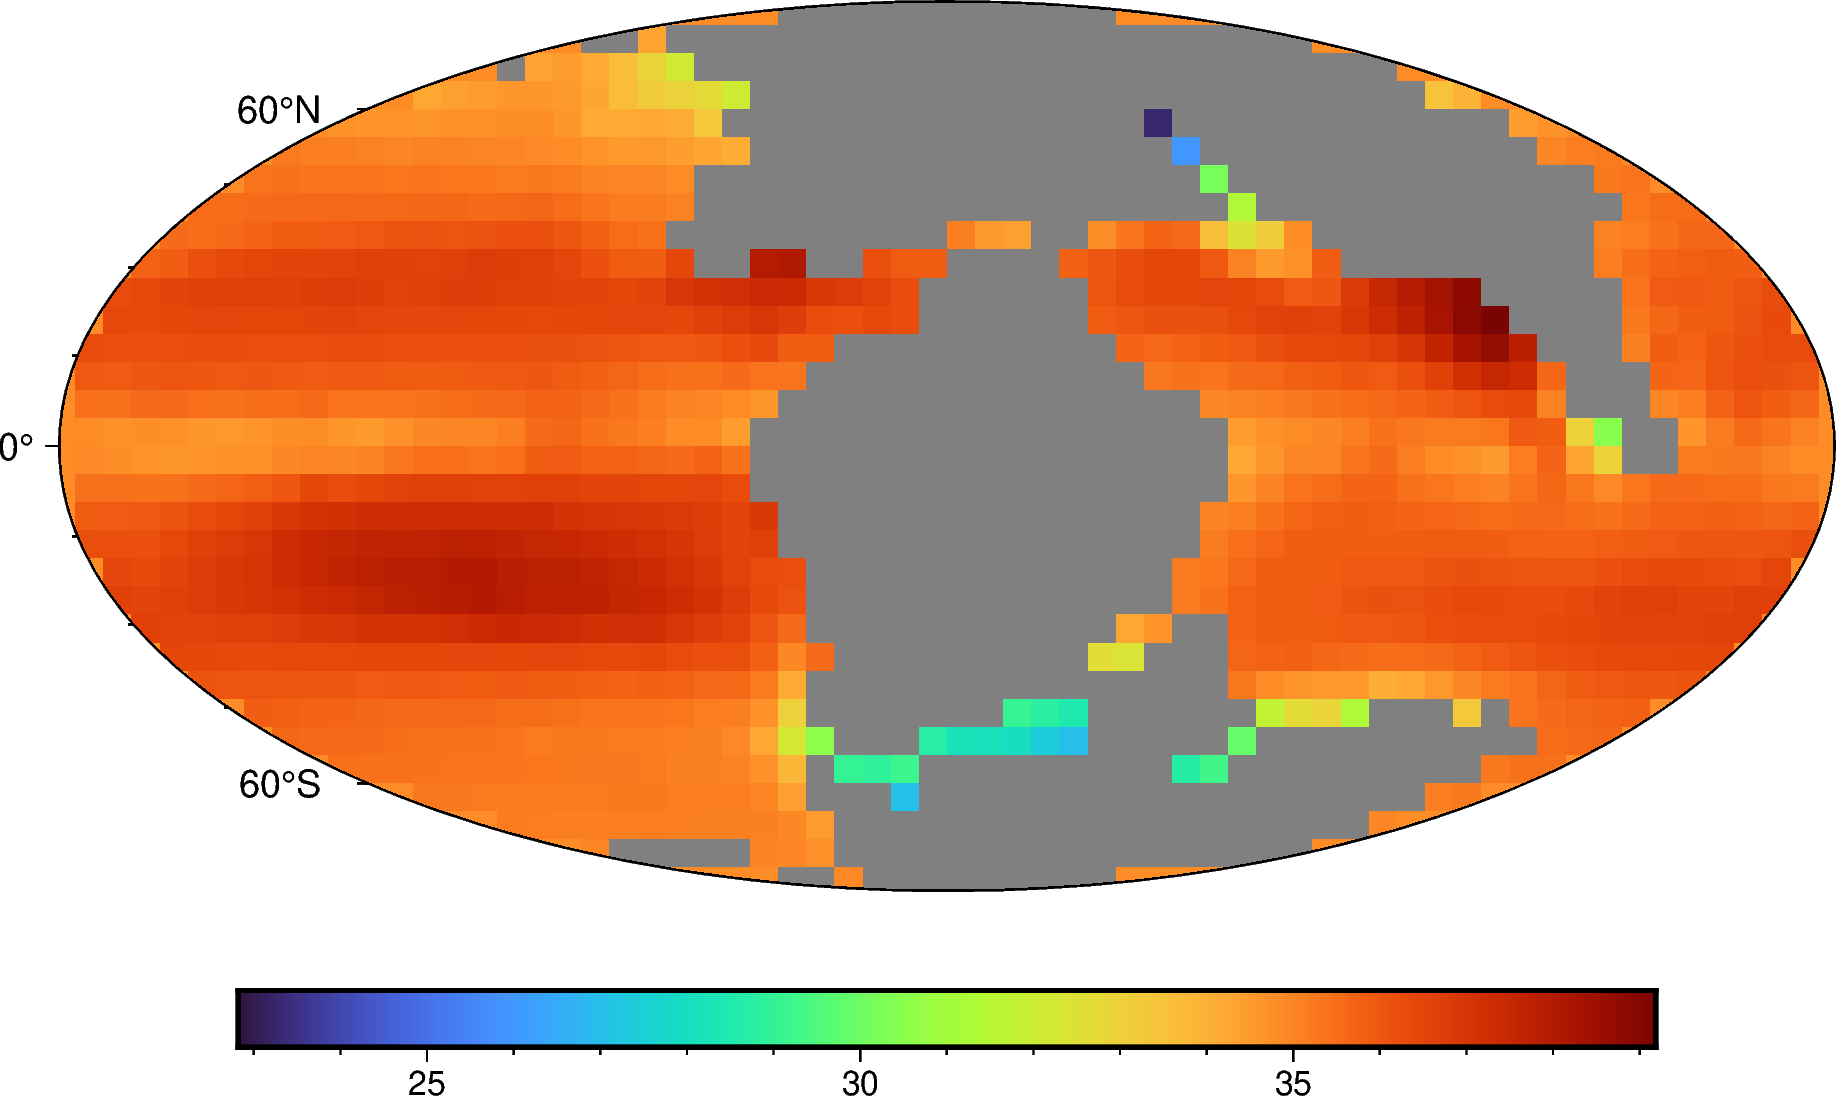

In [76]:
# Remove very low salinities
salinity = xr.where(salinity<22, np.nan, salinity)

fig = pygmt.Figure()
fig.basemap(region="d", projection="W15c", frame=True)
fig.grdimage(salinity)
fig.colorbar()
fig.show()

In [64]:
# Combine seasonal data to get summer and winter means
# SST
SST_DJF_northern = SST_DJF.where(SST_DJF.latitude<0,0)
SST_DJF_southern = SST_DJF.where(SST_DJF.latitude>0,0)

SST_JJA_northern = SST_JJA.where(SST_JJA.latitude<0,0)
SST_JJA_southern = SST_JJA.where(SST_JJA.latitude>0,0)

SST_summer = SST_DJF_northern + SST_JJA_southern
SST_winter = SST_DJF_southern + SST_JJA_northern

# Solar Insolation
solar_DJF_northern = solar_DJF.where(solar_DJF.latitude<0,0)
solar_DJF_southern = solar_DJF.where(solar_DJF.latitude>0,0)

solar_JJA_northern = solar_JJA.where(solar_JJA.latitude<0,0)
solar_JJA_southern = solar_JJA.where(solar_JJA.latitude>0,0)

solar_summer = solar_DJF_northern + solar_JJA_southern
solar_winter = solar_DJF_southern + solar_JJA_northern

In [65]:
# Check the difference between seasonal datasets
diff_SST = SST_summer - SST_winter

diff_solar = solar_summer - solar_winter

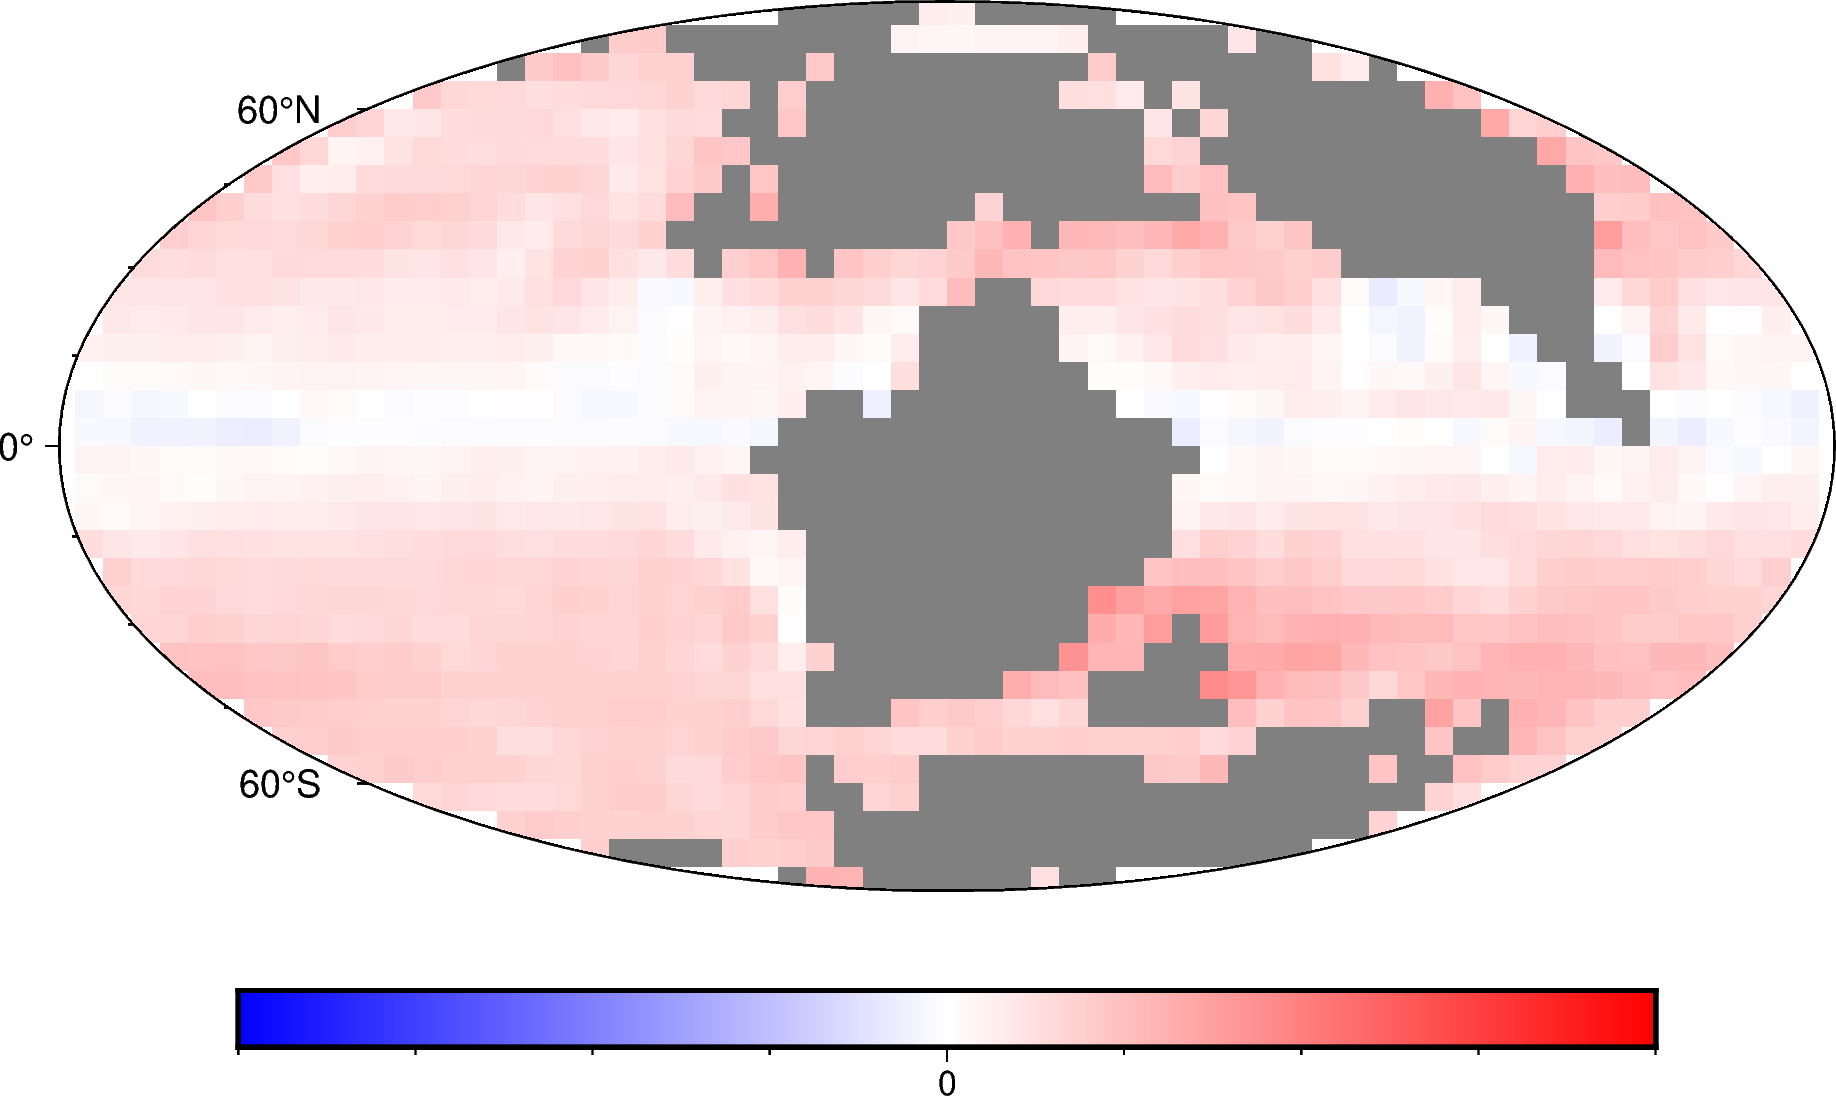

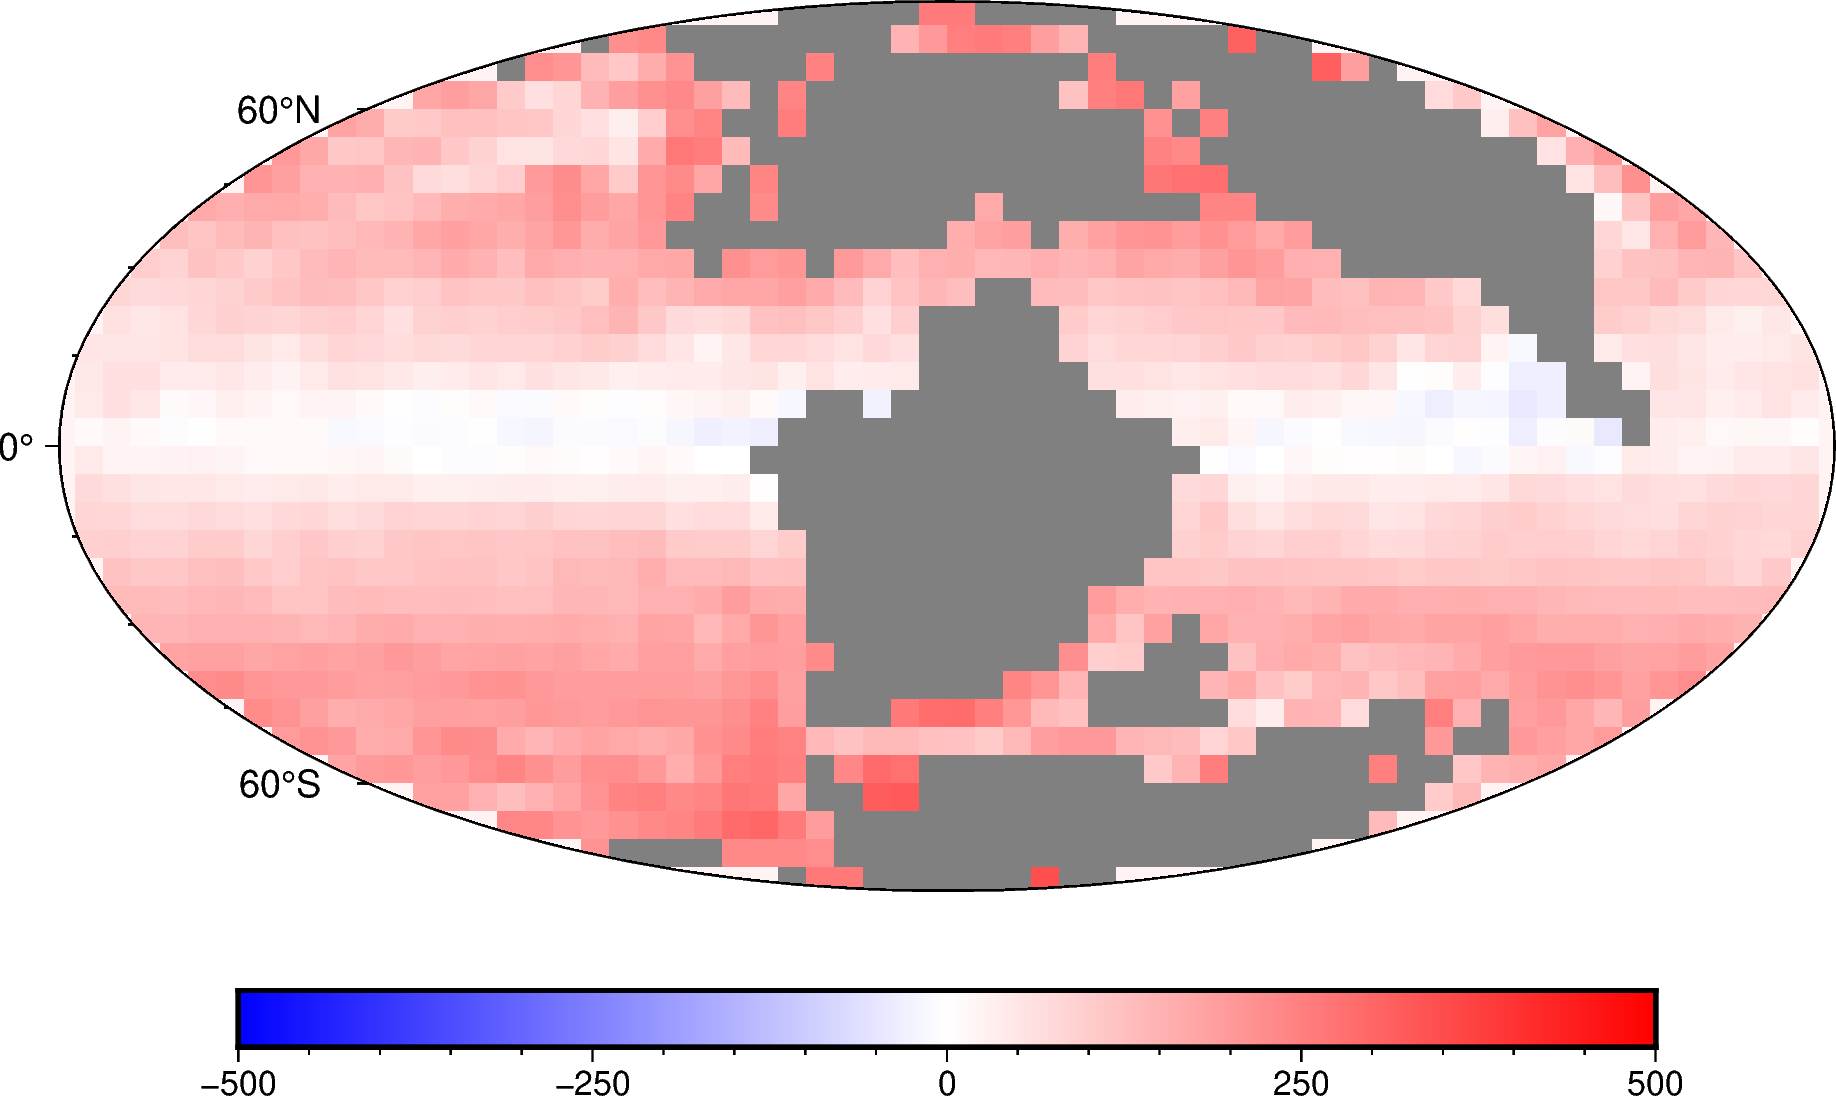

In [78]:
fig = pygmt.Figure()
cmap=pygmt.makecpt(cmap='polar', series=[-8,8])
fig.basemap(region="d", projection="W15c", frame=True)
fig.grdimage(diff_SST, cmap=cmap)
fig.colorbar(frame = 'a10f2', cmap=cmap)
fig.show()

fig = pygmt.Figure()
cmap=pygmt.makecpt(cmap='polar', series=[-500,500], background=True)
fig.basemap(region="d", projection="W15c", frame=True)
fig.grdimage(diff_solar, cmap=cmap)
fig.colorbar(frame = 'a250f50', cmap=cmap)
fig.show()

In [67]:
# Remove white space from meta data
# netsolar.attrs['long_name'] = 'netSolarHeatFlux'
bathymetry.attrs['long_name'] = 'oceanDepth'
upwelling.attrs['long_name'] = 'verticalCurrent'


In [68]:
# Convert to geoTiff
envRasterPath = f'data/rasters/{age}Ma_envRaster'
if not os.path.exists(envRasterPath):
    os.makedirs(envRasterPath)

surfaceTemp.rio.to_raster(f'{envRasterPath}/SST_annual.tif')
SST_summer.rio.to_raster(f'{envRasterPath}/SST_summer.tif')
SST_winter.rio.to_raster(f'{envRasterPath}/SST_winter.tif')

solar.rio.to_raster(f'{envRasterPath}/solar_annual.tif')
solar_summer.rio.to_raster(f'{envRasterPath}/solar_summer.tif')
solar_winter.rio.to_raster(f'{envRasterPath}/solar_winter.tif')

bathymetry.rio.to_raster(f'{envRasterPath}/bathymetry.tif')
salinity.rio.to_raster(f'{envRasterPath}/salinity_annual.tif')
upwelling.rio.to_raster(f'{envRasterPath}/upwelling_annual.tif')
runoff.rio.to_raster(f'{envRasterPath}/runoff_annual.tif')